# PCA Analysis Pipeline

This notebook implements a Principal Component Analysis (PCA) pipeline including data loading, preprocessing, PCA application, and visualization.

In [1]:
# Install necessary libraries if not already installed
!pip install numpy matplotlib scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

## 1. Load Dataset

In [3]:
# ======================
# 1. Load Dataset
# ======================
def load_dataset(dataset_name='iris'):
    # Function to load Iris or Wine dataset based on user choice
    if dataset_name.lower() == 'iris':
        data = load_iris()           # Load Iris dataset
        print(f"Loaded Iris dataset")
    elif dataset_name.lower() == 'wine':
        data = load_wine()           # Load Wine dataset
        print(f"Loaded Wine dataset")
    else:
        raise ValueError("Dataset must be 'iris' or 'wine'")  # Invalid dataset name

    X = data.data                   # Feature matrix
    y = data.target                 # Class labels
    feature_names = data.feature_names   # Feature names
    target_names = data.target_names     # Class names
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(target_names)}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)
    return X, y, feature_names, target_names

## 2. Preprocessing

In [4]:
# ======================
# 2. Preprocessing
# ======================
def preprocess_data(X):
    # Function to apply standardization and normalization
    scaler_standard = StandardScaler()        # Create StandardScaler object
    X_standardized = scaler_standard.fit_transform(X)  # Apply Z-score normalization
    scaler_minmax = MinMaxScaler()            # Create MinMaxScaler object
    X_normalized = scaler_minmax.fit_transform(X)  # Scale data to [0, 1]
    print("Data preprocessing completed:")
    print(f"  Original data range: [{X.min():.2f}, {X.max():.2f}]")
    print(f"  Standardized data mean: {X_standardized.mean():.2f}, std: {X_standardized.std():.2f}")
    print(f"  Normalized data range: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")
    print("-" * 50)
    return X_standardized, X_normalized

## 3. PCA Implementation

In [5]:
# ======================
# 3. PCA Implementation
# ======================
def apply_pca(X, n_components=2):
    # Function to apply PCA and reduce dimensionality
    pca = PCA(n_components=n_components)   # Initialize PCA object
    X_pca = pca.fit_transform(X)           # Fit PCA and transform data
    explained_variance_ratio = pca.explained_variance_ratio_  # Variance per PC
    cumulative_variance = np.cumsum(explained_variance_ratio)  # Cumulative variance
    print("PCA Results:")
    for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
        print(f"  PC{i + 1}: Explained Variance Ratio = {var:.4f} ({var * 100:.2f}%)")
        print(f"        Cumulative Variance = {cum_var:.4f} ({cum_var * 100:.2f}%)")
    print(f"\nTotal variance explained by {n_components} components: {cumulative_variance[-1]:.4f} ({cumulative_variance[-1] * 100:.2f}%)")
    print("-" * 50)
    return X_pca, pca, explained_variance_ratio, cumulative_variance

## 4. Visualization Functions

In [ ]:
# ======================
# 4. Visualization Functions
# ======================
def plot_pca_2d(X_pca, y, target_names, title="PCA Visualization (2D)"):
    # Function to visualize PCA results in 2D
    # Create figure
    # Visualize PCA in 2D
    plt.figure()
    for i, target in enumerate(target_names):
        plt.scatter(
            X_pca[y == i, 0],
            X_pca[y == i, 1],
            label=target
        )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA (2D Projection of Iris Dataset)")
    plt.legend()
    plt.show()

def plot_scree_plot(explained_variance_ratio, cumulative_variance, title="Scree Plot"):
    # Function to plot scree plot
    components = np.arange(1, len(explained_variance_ratio) + 1)  # PC indices
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.bar(components, explained_variance_ratio, alpha=0.6)  # Individual variance bars
    ax1.set_xlabel('Principal Components')
    ax1.set_ylabel('Explained Variance Ratio')
    ax1.set_xticks(components)
    ax2 = ax1.twinx()  # Secondary y-axis
    ax2.plot(components, cumulative_variance, 'ro-')  # Cumulative variance line
    ax2.set_ylabel('Cumulative Explained Variance')
    ax2.set_ylim([0, 1.1])
    plt.title(title)
    fig.tight_layout()
    plt.show()



def compare_original_vs_pca(X, X_pca, y, target_names, feature_names):
    # Function to compare original data and PCA-transformed data
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, target_name in enumerate(target_names):
        axes[0].scatter(X[y == i, 0], X[y == i, 1], label=target_name)
    axes[0].set_title(f'Original Data ({feature_names[0]} vs {feature_names[1]})')
    axes[0].legend()
    axes[0].grid(True)
    for i, target_name in enumerate(target_names):
        axes[1].scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target_name)
    axes[1].set_title('PCA Data (PC1 vs PC2)')
    axes[1].legend()
    axes[1].grid(True)
    X_norm = MinMaxScaler().fit_transform(X[:, :2]) * 2 - 1  # Normalize original data
    axes[2].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, label='PCA')
    axes[2].scatter(X_norm[:, 0], X_norm[:, 1], alpha=0.3, label='Original')
    for idx in np.random.choice(len(X), 10, replace=False):
        axes[2].arrow(
            X_norm[idx, 0],
            X_norm[idx, 1],
            X_pca[idx, 0] - X_norm[idx, 0],
            X_pca[idx, 1] - X_norm[idx, 1],
            alpha=0.4
        )
    axes[2].set_title('Original vs PCA Mapping')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

## 5. Main Execution

Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Data preprocessing completed:
  Original data range: [0.10, 7.90]
  Standardized data mean: -0.00, std: 1.00
  Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
  PC1: Explained Variance Ratio = 0.7296 (72.96%)
        Cumulative Variance = 0.7296 (72.96%)
  PC2: Explained Variance Ratio = 0.2285 (22.85%)
        Cumulative Variance = 0.9581 (95.81%)

Total variance explained by 2 components: 0.9581 (95.81%)
--------------------------------------------------


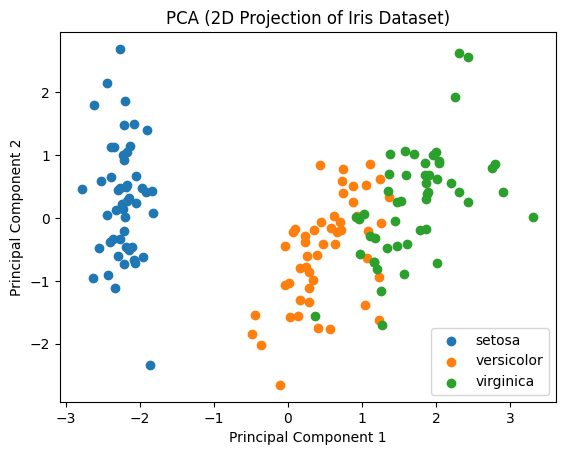

PCA Results:
  PC1: Explained Variance Ratio = 0.7296 (72.96%)
        Cumulative Variance = 0.7296 (72.96%)
  PC2: Explained Variance Ratio = 0.2285 (22.85%)
        Cumulative Variance = 0.9581 (95.81%)
  PC3: Explained Variance Ratio = 0.0367 (3.67%)
        Cumulative Variance = 0.9948 (99.48%)
  PC4: Explained Variance Ratio = 0.0052 (0.52%)
        Cumulative Variance = 1.0000 (100.00%)

Total variance explained by 4 components: 1.0000 (100.00%)
--------------------------------------------------


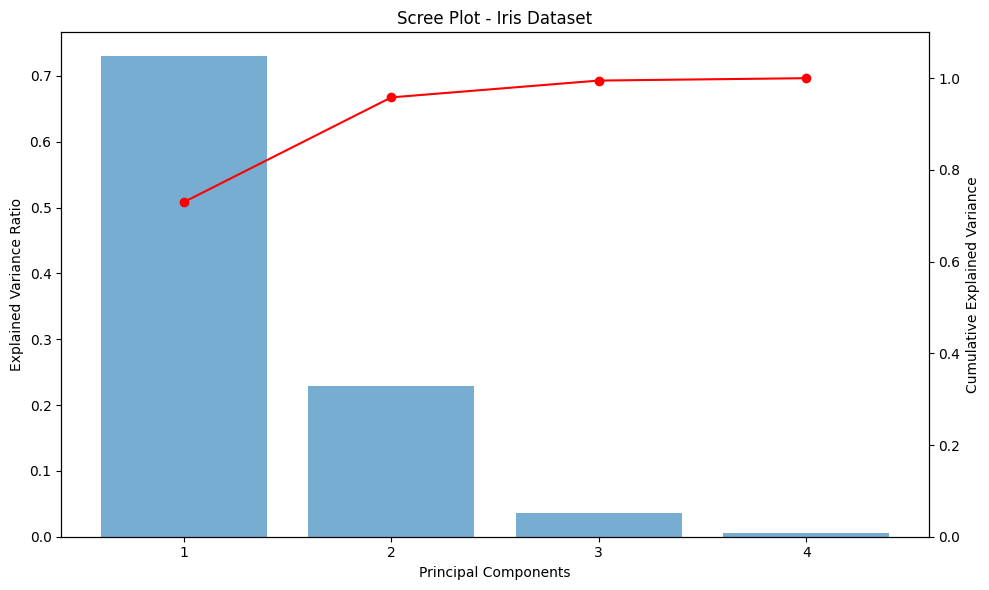

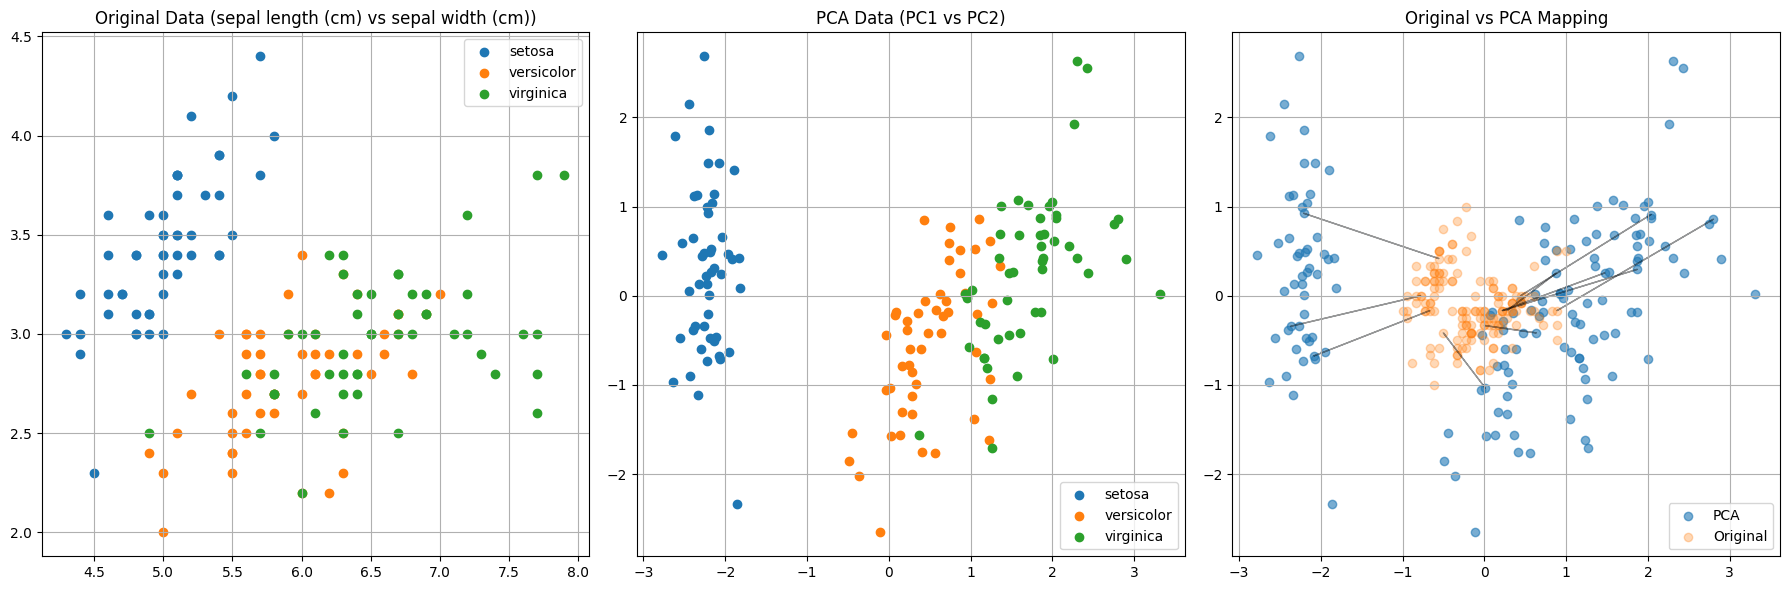

In [7]:
# ======================
# 5. Main Execution
# ======================
# Load the dataset
X, y, feature_names, target_names = load_dataset('iris')

# Preprocess the data
X_standardized, X_normalized = preprocess_data(X)

# Apply PCA with 2 components
X_pca, pca, explained_variance_ratio, cumulative_variance = apply_pca(X_standardized, n_components=2)

# Visualize PCA results
plot_pca_2d(X_pca, y, target_names, title="PCA Visualization - Iris Dataset")

# Apply PCA with all components for scree plot
X_pca_full, pca_full, explained_variance_ratio_full, cumulative_variance_full = apply_pca(X_standardized, n_components=min(X.shape))

# Plot scree plot
plot_scree_plot(explained_variance_ratio_full, cumulative_variance_full, title="Scree Plot - Iris Dataset")

# Compare original vs PCA
compare_original_vs_pca(X, X_pca, y, target_names, feature_names)

# POST LAB


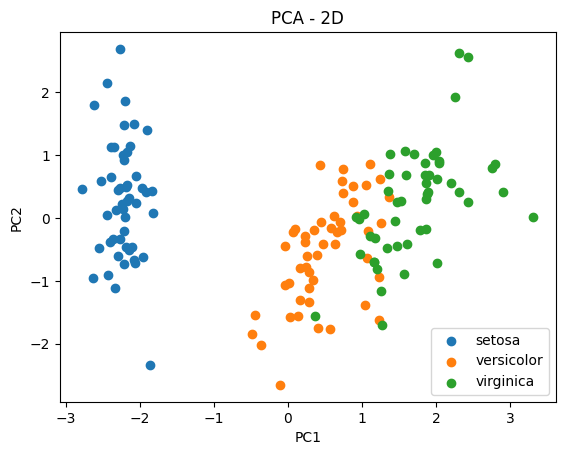

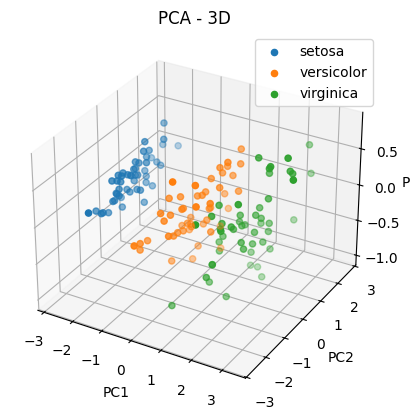

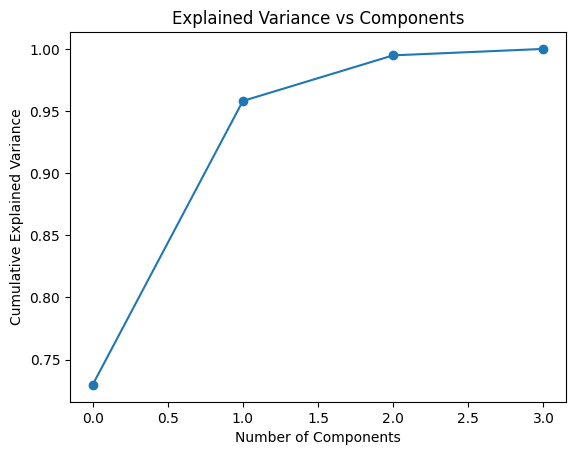

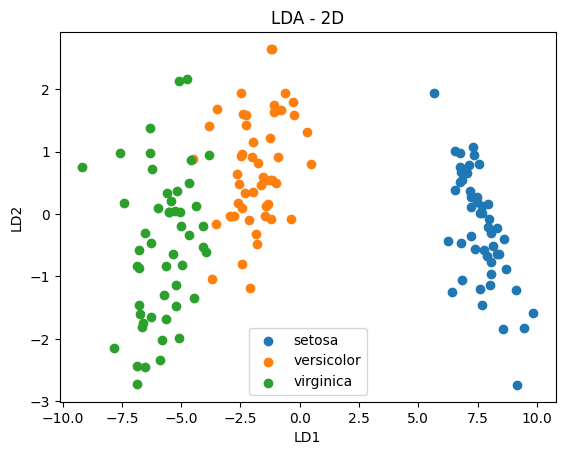

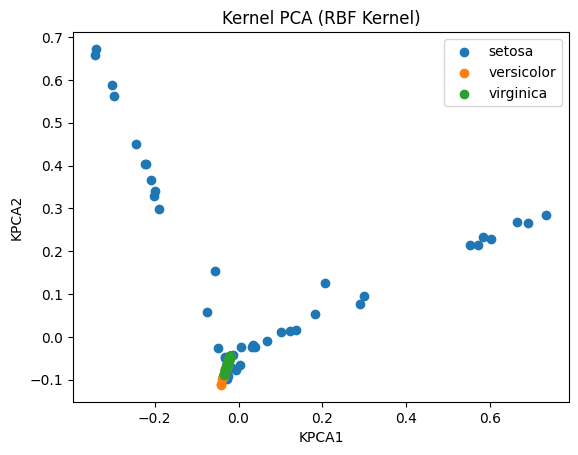

Reconstruction Error (MSE): 0.041867927999983595


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# PCA (2D Visualization)
# ===============================
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure()
for label in np.unique(y):
    plt.scatter(X_pca_2[y == label, 0], X_pca_2[y == label, 1], label=iris.target_names[label])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA - 2D")
plt.show()

# ===============================
# PCA (3D Visualization)
# ===============================
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for label in np.unique(y):
    ax.scatter(X_pca_3[y == label, 0],
               X_pca_3[y == label, 1],
               X_pca_3[y == label, 2],
               label=iris.target_names[label])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.title("PCA - 3D")
plt.show()

# ===============================
# Explained Variance Analysis
# ===============================
pca_full = PCA()
pca_full.fit(X_scaled)

plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Components")
plt.show()

# ===============================
# PCA vs LDA Comparison
# ===============================
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure()
for label in np.unique(y):
    plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=iris.target_names[label])
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.title("LDA - 2D")
plt.show()

# ===============================
# Kernel PCA (Non-linear)
# ===============================
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X_scaled)

plt.figure()
for label in np.unique(y):
    plt.scatter(X_kpca[y == label, 0], X_kpca[y == label, 1], label=iris.target_names[label])
plt.xlabel("KPCA1")
plt.ylabel("KPCA2")
plt.legend()
plt.title("Kernel PCA (RBF Kernel)")
plt.show()

# ===============================
# Reconstruction & Error
# ===============================
pca_recon = PCA(n_components=2)
X_reduced = pca_recon.fit_transform(X_scaled)
X_reconstructed = pca_recon.inverse_transform(X_reduced)

reconstruction_error = mean_squared_error(X_scaled, X_reconstructed)
print("Reconstruction Error (MSE):", reconstruction_error)
